### Stochastic Model Functions

In [171]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

In [111]:
np.random.seed(10)

In [7]:
def process_probabilities(state, params):
    X,Y,Z = state['X'], state['Y'], state['Z']
    a = np.zeros(6)   
    a[0] = (params['beta'] * X*Y)/(X+Y+Z)# Transmission rate
    a[1] = params['gamma'] * Y# Recovery Rates
    a[2] = params['mu']*(X+Y+Z) #Birth
    a[3] = params['mu']*(X)
    a[4] = params['mu']*(Y)
    a[5] = params['mu']*(Z)
    return a

def process(probs):
    r = np.random.random() * sum(probs)
    which = 0
    cumulative_sum = probs[0]    
    while r > cumulative_sum:
        which += 1
        cumulative_sum += probs[which]
    return which + 1


### Plot Results for the Stochastic Model

In [9]:
def plot_results(meanTime, meanS, meanI, meanR):
    plt.figure(figsize=(10, 6))      
    plt.plot(meanTime, meanS, label='Susceptible', linestyle='-')
    plt.plot(meanTime, meanI, label='Infected', linestyle='-')
    plt.plot(meanTime, meanR, label='Recovered', linestyle='-')
    plt.xlabel('Time')
    plt.ylabel('Population')
    plt.title('Mean SIR Model Simulation')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


### Function to Simulate a Stochastic Model 

In [11]:
def SIR_stoch(params, initial, end_time):
    state = initial.copy()
    time = 0
    result = {'time': [], 'X': [], 'Y': [], 'Z': []}
    while time < end_time and state['Y'] > 0:
        
        probs = process_probabilities(state, params)
        tau = (1 / sum(probs)) * np.log(1 / np.random.random())
        time += tau
        which = process(probs)

        if which == 1:
            state['X'] -= 1  # infection
            state['Y'] += 1
        elif which == 2:
            state['Y'] -= 1  # recovery
            state['Z'] += 1
        elif which == 3:  # Birth event
            state['X'] += 1 
        elif which ==4:
            state['X']-=1
        elif which ==5:
            state['Y']-=1
        elif which ==6:
            state['Z']-=1

        result['time'].append(time)
        result['X'].append(state['X'])
        result['Y'].append(state['Y'])
        result['Z'].append(state['Z'])    
    return result


### Function to run a Stochastic Model Simulation over many Iterations

In [21]:
def SIR_stoch_run():
    params = {
        'beta': 1,  
        'gamma': 0.1,
        'mu':0.02/365
    }
    initial = {
        'X': 9999,     
        'Y': 1,     
        'Z': 0      
    }
    
    end_time = 50  # end of simulation time span starting at 0
    run_count = 50 # number of runs
    result = {'time': [], 'X': [], 'Y': [], 'Z': []}
    for n in range(run_count):
        out = SIR_stoch(params, initial, end_time)
        result['time'].extend(out['time'])
        result['X'].extend(out['X'])
        result['Y'].extend(out['Y'])
        result['Z'].extend(out['Z'])
    
    #Extract all the unique time points from the simulations 
    time, unique_indices = np.unique(result['time'], return_index=True)
    X = np.array(result['X'])[unique_indices]
    Y = np.array(result['Y'])[unique_indices]
    Z = np.array(result['Z'])[unique_indices]
 
    n = 100
    meanTime, meanS, meanI, meanR = [], [], [], []
    for i in range(0, len(time) - n + 1, n):
        meanTime.append(np.mean(time[i:i+n]))
        meanS.append(np.mean(X[i:i+n]))
        meanI.append(np.mean(Y[i:i+n]))
        meanR.append(np.mean(Z[i:i+n]))    
    plot_results(meanTime, meanS, meanI, meanR)

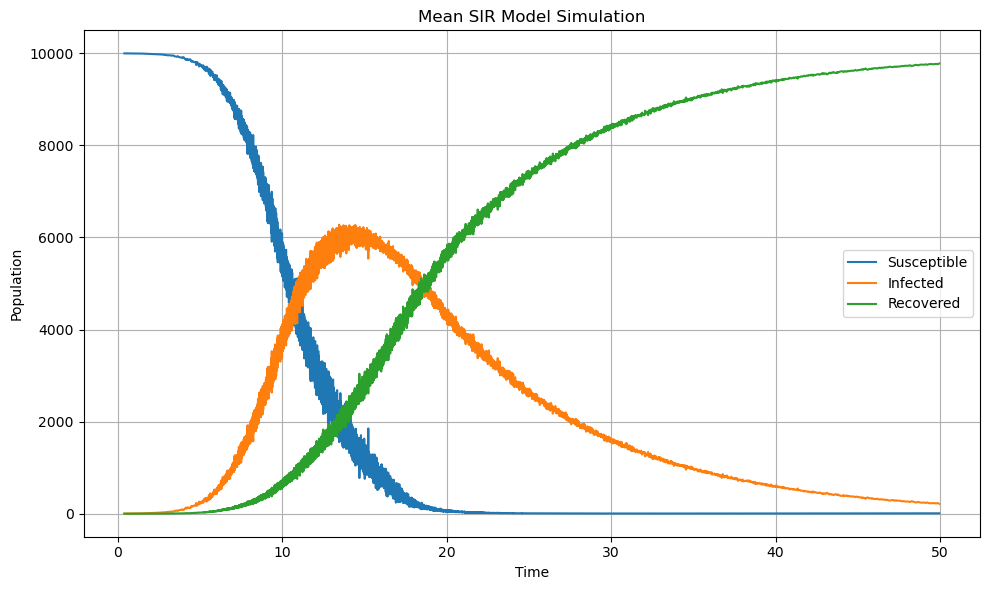

In [15]:
SIR_stoch_run()

### Deterministic SIR Model 

In [23]:
def SIR_deterministic(y, t, beta, gamma,mu):
    X,Y,Z = y
    N=X+Y+Z
    dXdt = -beta * X*Y/N + mu*N-mu*X
    dYdt = beta * X*Y/N - gamma * Y-mu*Y
    dZdt = gamma * Y-mu*Z
    return [dXdt, dYdt, dZdt]

### Function to Plot Comparison between Stochastic and Deterministic Model 

In [25]:
def plot_comparison(meanTime, meanS, meanI, meanR, t_d, X_d, Y_d, Z_d):
    plt.figure(figsize=(12, 8))      

    plt.subplot(3, 1, 1)
    plt.plot(meanTime, meanS, label='Stochastic (Mean Susceptible)', linestyle='-')
    plt.plot(t_d, X_d, label='Deterministic Susceptible', linestyle='--')
    plt.ylabel('Population (X)')
    plt.legend()

    plt.subplot(3, 1, 2)
    plt.plot(meanTime, meanI, label='Stochastic (Mean Infected)', linestyle='-')
    plt.plot(t_d, Y_d, label='Deterministic Infected', linestyle='--')
    plt.ylabel('Population (Y)')
    plt.legend()

    plt.subplot(3, 1, 3)
    plt.plot(meanTime, meanR, label='Stochastic (Mean Recovered)', linestyle='-')
    plt.plot(t_d, Z_d, label='Deterministic Recovered', linestyle='--')
    plt.xlabel('Time')
    plt.ylabel('Population (Z)')
    plt.legend()

    plt.tight_layout()
    plt.show()


### Function to Compare Stochastic and Deterministic Model 

In [27]:
def compare_stochastic_deterministic_SIR(X=999):
    params = {
        'beta': 1,
        'gamma': 0.1,
        'mu':0.02/365
    }
    initial_stoch = {
        'X': X,
        'Y': 1,
        'Z': 0
    }
    initial_det = [X, 1, 0]
    
    end_time = 50  # end of simulation time span starting at 0

    # Run stochastic simulation
    stoch_results = SIR_stoch(params, initial_stoch, end_time)

    # Prepare time points for deterministic model
    time_points = np.linspace(0, end_time, 100)

    # Run deterministic model
    det_results = odeint(SIR_deterministic, initial_det, time_points, args=(params['beta'], params['gamma'], params['mu']))
    
    # Plotting the results
    plt.figure(figsize=(10, 6))
    plt.plot(stoch_results['time'], stoch_results['X'], label='Stochastic Susceptible', color='blue', linestyle='-')
    plt.plot(stoch_results['time'], stoch_results['Y'], label='Stochastic Infected', color='red', linestyle='-')
    plt.plot(stoch_results['time'], stoch_results['Z'], label='Stochastic Recovered', color='green', linestyle='-')
    
    plt.plot(time_points, det_results[:, 0], label='Deterministic Susceptible', color='blue', linestyle='--')
    plt.plot(time_points, det_results[:, 1], label='Deterministic Infected', color='red', linestyle='--')
    plt.plot(time_points, det_results[:, 2], label='Deterministic Recovered', color='green', linestyle='--')
    
    plt.xlabel('Time')
    plt.ylabel('Population')
    plt.title('Comparison of Stochastic and Deterministic SIR Models')
    plt.legend()
    plt.grid()
    plt.tight_layout()
    plt.show()


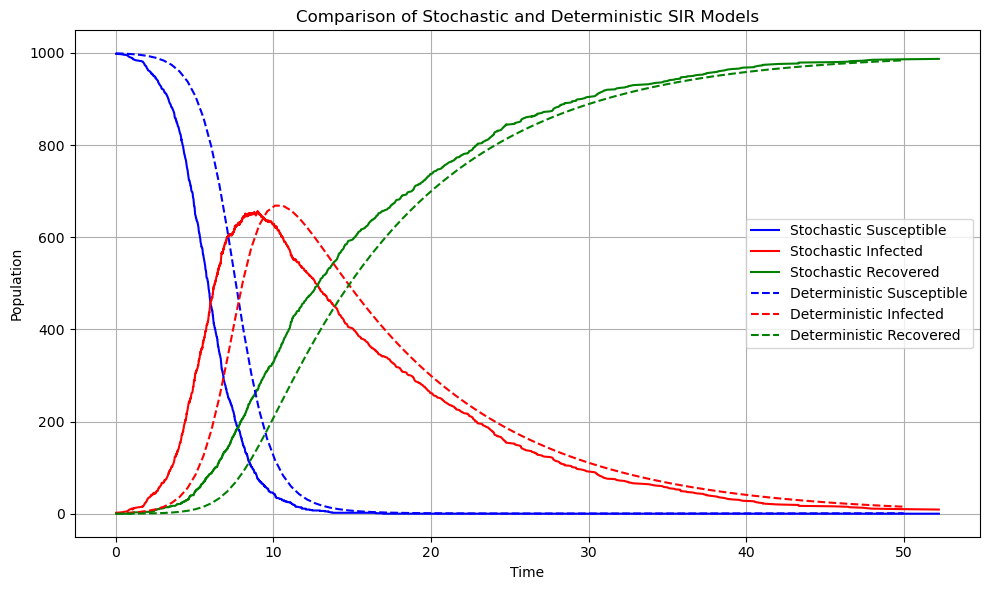

In [29]:
compare_stochastic_deterministic_SIR()

### Problem 1.2 Variance, covariance, mean

In [233]:
def SIR_stoch_variance_covariance(X=99):
    params = {
        'beta': 1,  
        'gamma': 0.1,
        'mu': 0.02/365  # Birth and death rate
    }
    initial = {
        'X': X,  # Initial susceptible population
        'Y': 1,  # Initial infected population
        'Z': 0   # Initial recovered population
    }
    
    end_time = 50  # End of simulation time span starting at 0
    run_count = 50  # Number of simulation runs
    num_points = 50  # Number of points on the common time grid

    # Define the common time points for interpolation
    time_grid = np.linspace(0, end_time, num_points)  # Evenly spaced time points from 0 to end_time

    # Initialize lists to store interpolated results for each run
    S_values = []
    I_values = []
    R_values = []

    result = []  # To store results from each run
    
    # for n in range(1):
    for n in range(run_count):
        # Run the stochastic SIR model
        out = SIR_stoch(params, initial, end_time)
        result.append({'time': out['time'], 'X': out['X'], 'Y': out['Y'], 'Z': out['Z']})

        # Extract time points and corresponding S (X), I (Y), and R (Z)
        time_points = out['time']
        S = out['X']
        I = out['Y']
        R = out['Z']

        # Remove the results where the population got extinct after only a few time steps
        if len(time_points) < num_points:
            continue

        # Use linear interpolation to get S, I, R at the common time points
        S_interp = np.interp(time_grid,time_points,S)
        I_interp = np.interp(time_grid,time_points,I)
        R_interp = np.interp(time_grid,time_points,R)

        # Append interpolated values to the lists
        S_values.append(S_interp)
        I_values.append(I_interp)
        R_values.append(R_interp)

    # Convert lists to numpy arrays for easier calculations (shape: [run_count, num_points])
    S_values = np.array(S_values)
    I_values = np.array(I_values)
    R_values = np.array(R_values)

    # Calculate the mean at each time point (over all runs)
    mean_S = np.mean(S_values, axis=0)
    mean_I = np.mean(I_values, axis=0)
    mean_R = np.mean(R_values, axis=0)

    # Calculate the variance at each time point (over all runs)
    var_S = np.var(S_values, axis=0)
    var_I = np.var(I_values, axis=0)
    var_R = np.var(R_values, axis=0)

    # Calculate the covariance between S and I at each time point (over all runs)
    cov_SI = np.mean((S_values - mean_S) * (I_values - mean_I), axis=0)

    # Return the mean, variance, and covariance results
    return {
        'time_grid': time_grid,
        'mean_S': mean_S,
        'mean_I': mean_I,
        'mean_R': mean_R,
        'var_S': var_S,
        'var_I': var_I,
        'var_R': var_R,
        'cov_SI': cov_SI
    }

# Example usage:
result_1 = SIR_stoch_variance_covariance(X=1000)
# result_2 = SIR_stoch_variance_covariance(X=10000)
# result_3 = SIR_stoch_variance_covariance(X=100000)

In [177]:
print(result['mean_I'])
# print(min(result['var_I']))
# print(len(result['var_I']))

[2.03528402e+02 1.91708426e+02 1.92906411e+02 0.00000000e+00
 0.00000000e+00 0.00000000e+00 1.23514166e-01 1.91877966e+02
 1.90863192e+02 1.93142336e+02 0.00000000e+00 1.90345347e+02
 1.84590920e+02 1.93791535e+02 1.87905491e+02 1.82170456e+02
 1.96188384e+02 0.00000000e+00 2.03065801e+02 2.04245399e+02
 2.00342685e+02 1.89581570e+02 1.86523107e+02 1.92631422e+02
 2.00159645e+02 1.93715304e+02 1.85511302e+02 1.98107330e+02
 1.91588369e+02 1.97774636e+02 1.91011996e+02 1.92724613e+02
 1.81726724e+02 2.02460033e+02 1.94112701e+02 1.96774592e+02
 1.89154622e+02 1.94074389e+02 1.95637734e+02 1.83339382e+02
 1.88167128e+02 1.97003585e+02 1.93662307e+02 1.82682509e+02
 1.97184062e+02 1.92724638e+02 1.83598062e+02 1.94814801e+02
 1.86373719e+02 1.91566455e+02]


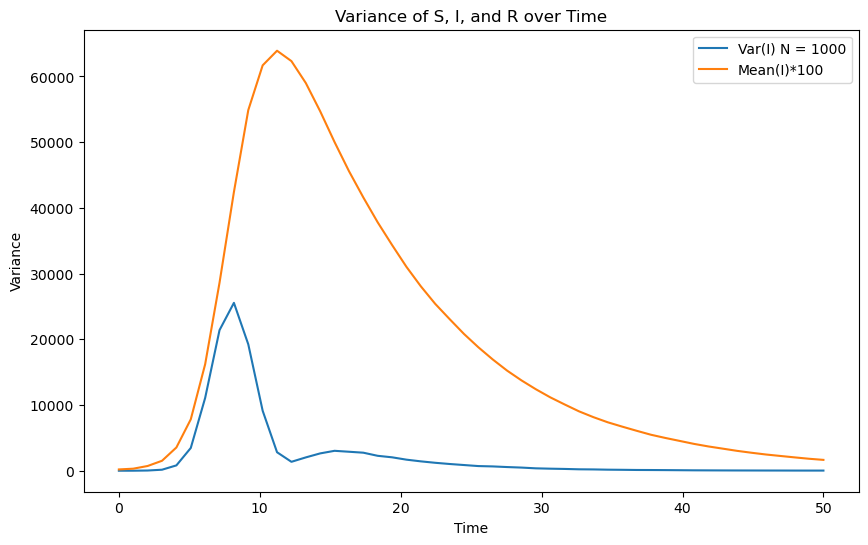

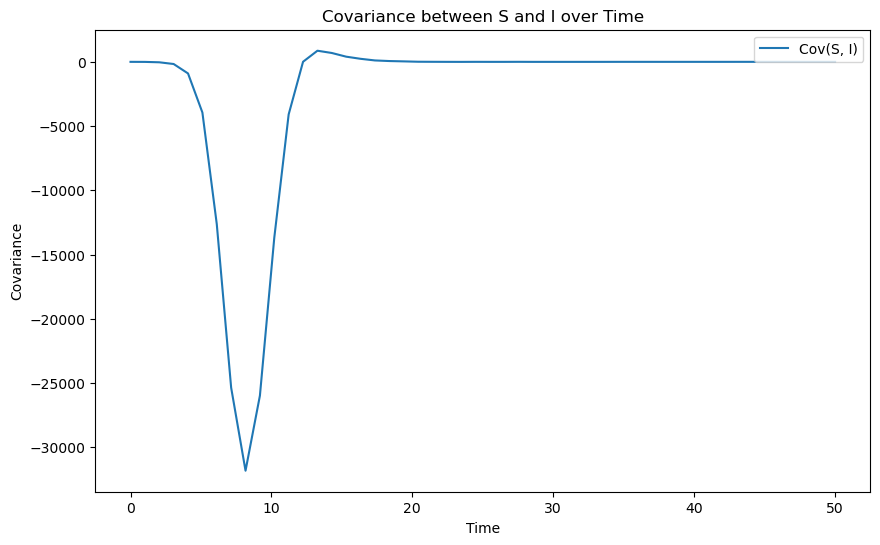

In [239]:
# Plot variance of S, I, and R over time
plt.figure(figsize=(10, 6))
plt.plot(result_1['time_grid'], [var for var in result_1['var_I']], label='Var(I) N = 1000')
# plt.plot(result_2['time_grid'], [var/10000 for var in result_2['var_I']], label='Var(I) N = 10000')
# plt.plot(result_3['time_grid'], [var/100000 for var in result_3['var_I']], label='Var(I) N = 100000')
plt.plot(result_1['time_grid'], [mean * 100 for mean in result_1['mean_I']], label='Mean(I)*100')
plt.xlabel('Time')
plt.ylabel('Variance')
plt.legend()
plt.title('Variance of S, I, and R over Time')
plt.show()

# Plot covariance between S and I over time
plt.figure(figsize=(10, 6))
plt.plot(result_1['time_grid'], result_1['cov_SI'], label='Cov(S, I)')
plt.xlabel('Time')
plt.ylabel('Covariance')
plt.legend()
plt.title('Covariance between S and I over Time')
plt.show()

In [143]:
print(result['mean_I'][40:50])

[196.34704109 195.43980808 189.61772367 174.79582506 190.27641121
 194.75255305 195.35731601 186.3165214  189.41378941 193.8079589 ]


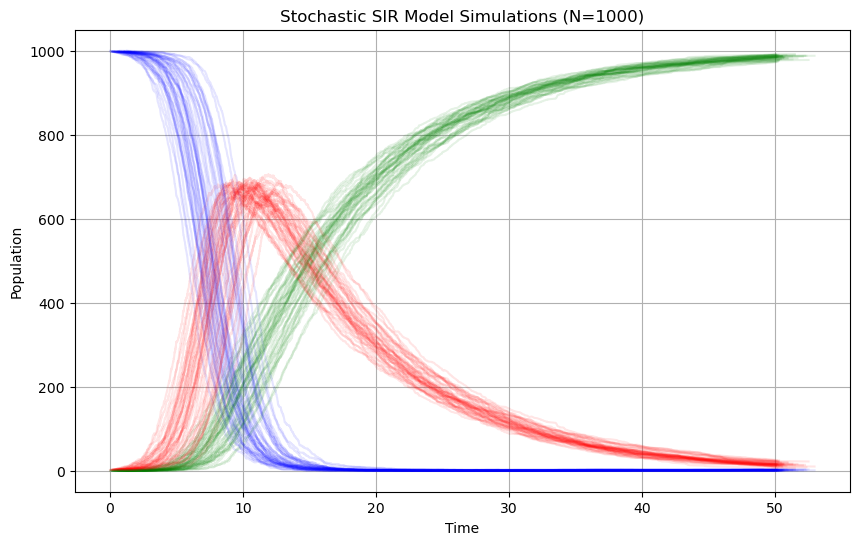

In [227]:

def run_and_plot_stochastic_simulations():
    params = {
        'beta': 1,  
        'gamma': 0.1,
        'mu': 0.02/365
    }
    initial = {
        'X': 999,     
        'Y': 1,     
        'Z': 0      
    }
    
    end_time = 50  # end of simulation time span starting at 0
    run_count = 50  # number of runs

    plt.figure(figsize=(10, 6))  # Create a new figure

    for n in range(run_count):
        out = SIR_stoch(params, initial, end_time)
        plt.plot(out['time'], out['X'], color='blue', alpha=0.1)  # Susceptible
        plt.plot(out['time'], out['Y'], color='red', alpha=0.1)   # Infected
        plt.plot(out['time'], out['Z'], color='green', alpha=0.1)  # Recovered
    
    plt.xlabel('Time')
    plt.ylabel('Population')
    plt.title(f'Stochastic SIR Model Simulations (N={initial["X"] + initial["Y"]})')
    plt.grid(True)
    plt.show()

run_and_plot_stochastic_simulations()

In [132]:
# Block 6: New Function to Vary Parameters and Calculate Covariance
def analyze_parameter_effects():
    beta_values = [0.1, 0.3, 0.5]  # Different infection rates
    N_values = [100, 1000, 10000]  # Different population sizes
    initial_infected = 1
    end_time = 50  # Duration of the simulation
    run_count = 50  # Number of simulations

    for beta in beta_values:
        for N in N_values:
            params = {'beta': beta, 'gamma': 0.1}  # Use fixed recovery rate
            initial = {'S': N - initial_infected, 'I': initial_infected, 'R': 0}
            all_I_means = []  # Store mean infected counts from all simulations
            all_S_means = []  # Store mean susceptible counts from all simulations

            for _ in range(run_count):
                out = SIR_stoch(params, initial, end_time)  # Run the stochastic simulation
                # Store the mean of the infected and susceptible populations
                all_I_means.append(np.mean(out['I']))  # Mean infected population
                all_S_means.append(np.mean(out['S']))  # Mean susceptible population

            # Calculate the covariance between the means of S and I
            S_mean = np.mean(all_S_means,axis=0)
            I_mean = np.mean(all_I_means,axis=0)
            covariance = np.cov(all_S_means, all_I_means)[0][1]

            print(f"Beta: {beta}, N: {N}, Covariance between mean S and mean I: {covariance:.2f}")

# Block 7: Call the new function to analyze parameter effects
analyze_parameter_effects()


Beta: 0.1, N: 100, Covariance between mean S and mean I: -73.20
Beta: 0.1, N: 1000, Covariance between mean S and mean I: 0.05
Beta: 0.1, N: 10000, Covariance between mean S and mean I: 1.44
Beta: 0.3, N: 100, Covariance between mean S and mean I: -0.13
Beta: 0.3, N: 1000, Covariance between mean S and mean I: 0.04
Beta: 0.3, N: 10000, Covariance between mean S and mean I: 1.95
Beta: 0.5, N: 100, Covariance between mean S and mean I: -0.05
Beta: 0.5, N: 1000, Covariance between mean S and mean I: 0.11
Beta: 0.5, N: 10000, Covariance between mean S and mean I: 2.10


In [128]:
def analyze_transients():
    beta_values = [0.1, 0.3, 0.5]  # Varying infection rates
    N_values = [100, 500, 1000]     # Varying population sizes
    initial_infected = 1
    end_time = 100  # Duration of the simulation
    run_count = 50  # Number of simulations

    results = []  # Store results for plotting

    for beta in beta_values:
        for N in N_values:
            params = {'beta': beta, 'gamma': 0.1}  # Fixed recovery rate
            initial = {'S': N - initial_infected, 'I': initial_infected, 'R': 0}
            max_infected_vals = []

            for _ in range(run_count):
                out = SIR_stoch(params, initial, end_time)
                max_infected_vals.append(out['max_infected'])

            # Calculate mean of maximum infected populations
            mean_max_infected = np.mean(max_infected_vals)
            results.append((beta, N, mean_max_infected))
            print(f"Beta: {beta}, N: {N}, Mean Max Infected: {mean_max_infected:.2f}")

    return results

# Block 3: Function to Plot Results
def plot_transients(results):
    betas = [r[0] for r in results]
    N_values = [r[1] for r in results]
    max_infected = [r[2] for r in results]

    plt.figure(figsize=(12, 6))
    scatter = plt.scatter(N_values, max_infected, c=betas, cmap='viridis', s=100)
    plt.colorbar(scatter, label='Beta')
    plt.xlabel('Population Size (N)')
    plt.ylabel('Mean Max Infected Population')
    plt.title('Mean Maximum Infected Population vs Population Size with Varying Beta')
    plt.grid()
    plt.tight_layout()
    plt.show()


In [130]:
results = analyze_transients()
plot_transients(results)

KeyError: 'max_infected'

/var/folders/_1/0wm31tv93_g2x0n62x6b_ht80000gn/T/ipykernel_98485/2885699929.py:23: ODEintWarning: Excess work done on this call (perhaps wrong Dfun type). Run with full_output = 1 to get quantitative information.
  det_results = odeint(SIR_deterministic, initial_det, time_points, args=(params['beta'], params['gamma'],params['mu']))


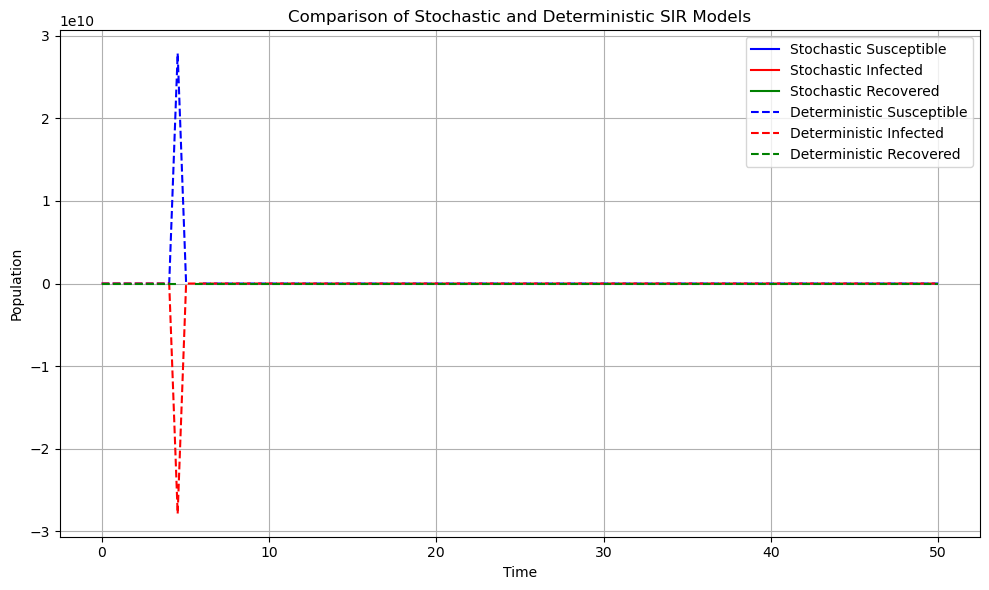

In [57]:
def compare_stochastic_deterministic_SIR():
    params = {
        'beta': 0.3,  # Adjusted beta
        'gamma': 0.1,
        'mu': 0.02/365
    }
    initial_stoch = {
        'X': 9999,
        'Y': 1,
        'Z': 0
    }
    initial_det = [9999, 1, 0]
    
    end_time = 50  # end of simulation time span starting at 0

    # Run stochastic simulation
    stoch_results = SIR_stoch(params, initial_stoch, end_time)

    # Prepare time points for deterministic model
    time_points = np.linspace(0, end_time, 100)

    # Run deterministic model
    det_results = odeint(SIR_deterministic, initial_det, time_points, args=(params['beta'], params['gamma'],params['mu']))
    
    # Plotting the results
    plt.figure(figsize=(10, 6))
    plt.plot(stoch_results['time'], stoch_results['X'], label='Stochastic Susceptible', color='blue', linestyle='-')
    plt.plot(stoch_results['time'], stoch_results['Y'], label='Stochastic Infected', color='red', linestyle='-')
    plt.plot(stoch_results['time'], stoch_results['Z'], label='Stochastic Recovered', color='green', linestyle='-')
    
    plt.plot(time_points, det_results[:, 0], label='Deterministic Susceptible', color='blue', linestyle='--')
    plt.plot(time_points, det_results[:, 1], label='Deterministic Infected', color='red', linestyle='--')
    plt.plot(time_points, det_results[:, 2], label='Deterministic Recovered', color='green', linestyle='--')
    
    plt.xlabel('Time')
    plt.ylabel('Population')
    plt.title('Comparison of Stochastic and Deterministic SIR Models')
    plt.legend()
    plt.grid()
    plt.tight_layout()
    plt.show()
compare_stochastic_deterministic_SIR()